# TDDE16 Project BBC news classification perfomrance between BERT and Naive Bayes and Logic regression
In this project I will use news categories from BBC which kaggle provides https://www.kaggle.com/competitions/learn-ai-bbc/overview

I will train and compare the performance of different techinques, namely googles BERT technology and some techinques performed in the lab


## 1: Fake new classification with Logic regression

In [2]:
#!pip3 install pandas
#!pip3 install spacy
#!pip3 install numpy

## Creating a Dataframe

In [4]:
# import the dataset and convert as a pandas dataframe
import pandas as pd
import spacy
import json
nlp = spacy.load('en_core_web_sm')

df = pd.read_json('News_Category_Dataset_V3.json', lines=True)
#Drop unneccecary columns
df = df.drop(df.columns[[0, 4, 5]], axis=1) 
df.head(10)


,headline,category,short_description
0,Over 4 Million Americans Roll Up Sleeves For O...,U.S. NEWS,Health experts said it is too early to predict...
1,"American Airlines Flyer Charged, Banned For Li...",U.S. NEWS,He was subdued by passengers and crew when he ...
2,23 Of The Funniest Tweets About Cats And Dogs ...,COMEDY,"""Until you have a dog you don't understand wha..."
3,The Funniest Tweets From Parents This Week (Se...,PARENTING,"""Accidentally put grown-up toothpaste on my to..."
4,Woman Who Called Cops On Black Bird-Watcher Lo...,U.S. NEWS,Amy Cooper accused investment firm Franklin Te...
5,Cleaner Was Dead In Belk Bathroom For 4 Days B...,U.S. NEWS,The 63-year-old woman was seen working at the ...
6,Reporter Gets Adorable Surprise From Her Boyfr...,U.S. NEWS,"""Who's that behind you?"" an anchor for New Yor..."
7,Puerto Ricans Desperate For Water After Hurric...,WORLD NEWS,More than half a million people remained witho...
8,How A New Documentary Captures The Complexity ...,CULTURE & ARTS,"In ""Mija,"" director Isabel Castro combined mus..."
9,Biden At UN To Call Russian War An Affront To ...,WORLD NEWS,White House officials say the crux of the pres...


### Visualize the categories

In [16]:
len(set(df.category))

42

<AxesSubplot: >

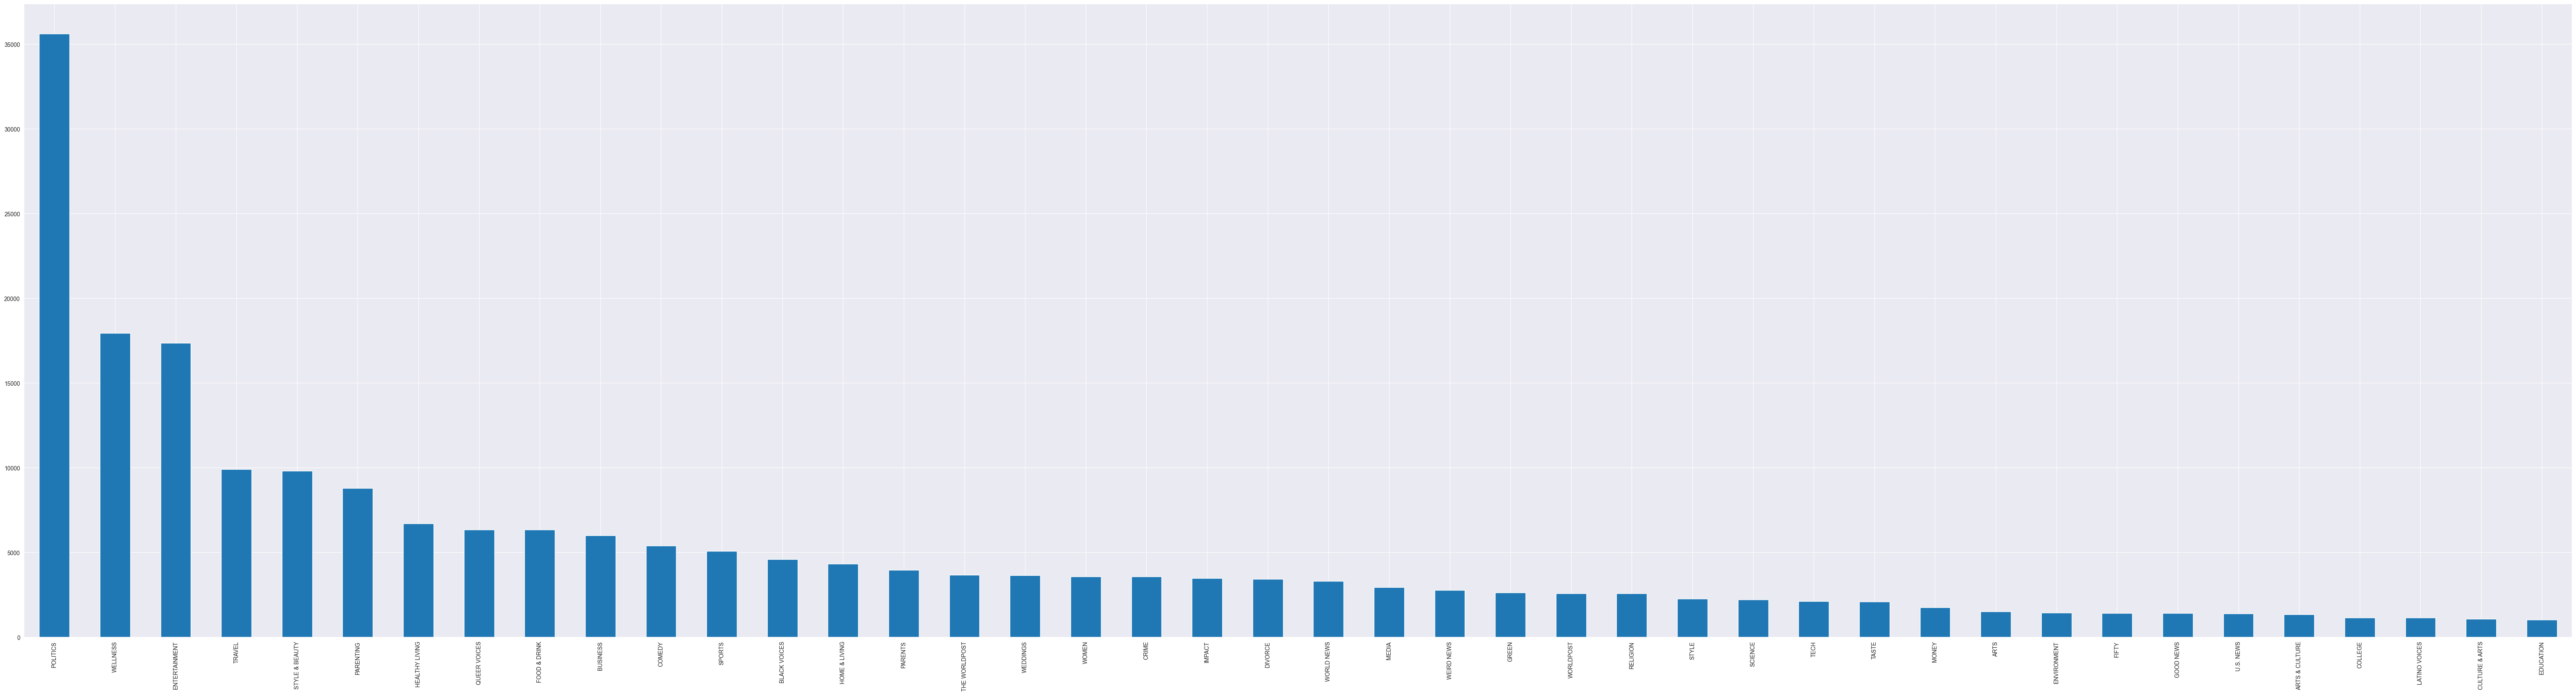

In [40]:
df.category.value_counts()
df.category.value_counts()[:42].plot(kind='bar')

It appears that the dataset is ubalanced with 35k topcis regarding politics and after that 18k with wellness

### Create a test and training set

In [43]:
from sklearn.model_selection import train_test_split
X = df['short_description']
y = df['category']
#Create 
X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=0.75, shuffle=True, random_state=42)

### Preprocess the data
A small preprocess is done to remove stop words, make sure it is alphabet and lemmatize all the words.

In [6]:
def preprocess(text):
    doc_list = []
    doc = nlp(text)
    for token in doc:
        if not token.is_stop and token.is_alpha:
                doc_list.append(token.lemma_)
            

    return doc_list

## Using naive bayes as a baseline

Now we will create a training and test set from the dataframe

Simmilar to the labs I will test the MultinomialNB with a count Vectorizer to show the score

In [44]:
from sklearn.naive_bayes import MultinomialNB
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report
from sklearn.feature_extraction.text import TfidfVectorizer


pipe = Pipeline(steps=[('countVec', TfidfVectorizer()), ('multNB', MultinomialNB())])

pipe.fit(X_train, y_train)
pred = pipe.predict(X_test)
print(classification_report(y_test, pred))
 

/Users/simonjakobsson/Documents/School/Year5/TDDE16/TDDE16_project/env/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1334: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/Users/simonjakobsson/Documents/School/Year5/TDDE16/TDDE16_project/env/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1334: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


                precision    recall  f1-score   support

          ARTS       0.00      0.00      0.00       364
ARTS & CULTURE       0.00      0.00      0.00       330
  BLACK VOICES       1.00      0.00      0.00      1141
      BUSINESS       1.00      0.00      0.00      1492
       COLLEGE       0.00      0.00      0.00       243
        COMEDY       0.00      0.00      0.00      1306
         CRIME       0.00      0.00      0.00       901
CULTURE & ARTS       0.00      0.00      0.00       257
       DIVORCE       1.00      0.01      0.01       827
     EDUCATION       0.00      0.00      0.00       252
 ENTERTAINMENT       0.42      0.32      0.36      4281
   ENVIRONMENT       0.00      0.00      0.00       373
         FIFTY       0.00      0.00      0.00       343
  FOOD & DRINK       0.62      0.15      0.24      1578
     GOOD NEWS       0.00      0.00      0.00       345
         GREEN       0.00      0.00      0.00       656
HEALTHY LIVING       0.00      0.00      0.00  

/Users/simonjakobsson/Documents/School/Year5/TDDE16/TDDE16_project/env/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1334: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


Getting a baseline from dummytest

In [8]:
from sklearn.dummy import DummyClassifier
dummy_clf = DummyClassifier(strategy="stratified")
dummy_clf.fit(X_train,y_train)
dummy_prediction = dummy_clf.predict(X_train)

print(classification_report(y_train, dummy_prediction))

                precision    recall  f1-score   support

          ARTS       0.00      0.00      0.00      1216
ARTS & CULTURE       0.00      0.00      0.00      1064
  BLACK VOICES       0.02      0.02      0.02      3694
      BUSINESS       0.02      0.02      0.02      4776
       COLLEGE       0.00      0.00      0.00       942
        COMEDY       0.03      0.02      0.03      4378
         CRIME       0.02      0.02      0.02      2849
CULTURE & ARTS       0.01      0.01      0.01       872
       DIVORCE       0.01      0.02      0.02      2762
     EDUCATION       0.00      0.00      0.00       805
 ENTERTAINMENT       0.08      0.08      0.08     13943
   ENVIRONMENT       0.01      0.01      0.01      1131
         FIFTY       0.01      0.01      0.01      1138
  FOOD & DRINK       0.03      0.03      0.03      5070
     GOOD NEWS       0.00      0.00      0.00      1128
         GREEN       0.01      0.01      0.01      2090
HEALTHY LIVING       0.03      0.03      0.03  

## Using logistic regression


In [46]:
from sklearn.linear_model import LogisticRegression
from sklearn.feature_extraction.text import CountVectorizer

pipe = Pipeline([('countVec', CountVectorizer()), ('logisticReg', LogisticRegression(max_iter=1000))])
pipe.fit(X_train, y_train)
prediction = pipe.predict(X_test)
print(classification_report(y_test ,prediction))


                precision    recall  f1-score   support

          ARTS       0.27      0.07      0.11       364
ARTS & CULTURE       0.21      0.07      0.11       330
  BLACK VOICES       0.33      0.19      0.24      1141
      BUSINESS       0.35      0.27      0.31      1492
       COLLEGE       0.32      0.17      0.22       243
        COMEDY       0.24      0.13      0.17      1306
         CRIME       0.38      0.26      0.31       901
CULTURE & ARTS       0.30      0.16      0.21       257
       DIVORCE       0.62      0.50      0.55       827
     EDUCATION       0.39      0.18      0.24       252
 ENTERTAINMENT       0.36      0.48      0.41      4281
   ENVIRONMENT       0.41      0.20      0.27       373
         FIFTY       0.22      0.07      0.11       343
  FOOD & DRINK       0.50      0.53      0.52      1578
     GOOD NEWS       0.18      0.03      0.06       345
         GREEN       0.29      0.15      0.19       656
HEALTHY LIVING       0.20      0.14      0.16  

## Confusion matrix of the different baselines

/Users/simonjakobsson/Documents/School/Year5/TDDE16/TDDE16_project/env/lib/python3.11/site-packages/sklearn/utils/deprecation.py:87: FutureWarning: Function plot_confusion_matrix is deprecated; Function `plot_confusion_matrix` is deprecated in 1.0 and will be removed in 1.2. Use one of the class methods: ConfusionMatrixDisplay.from_predictions or ConfusionMatrixDisplay.from_estimator.
  warnings.warn(msg, category=FutureWarning)


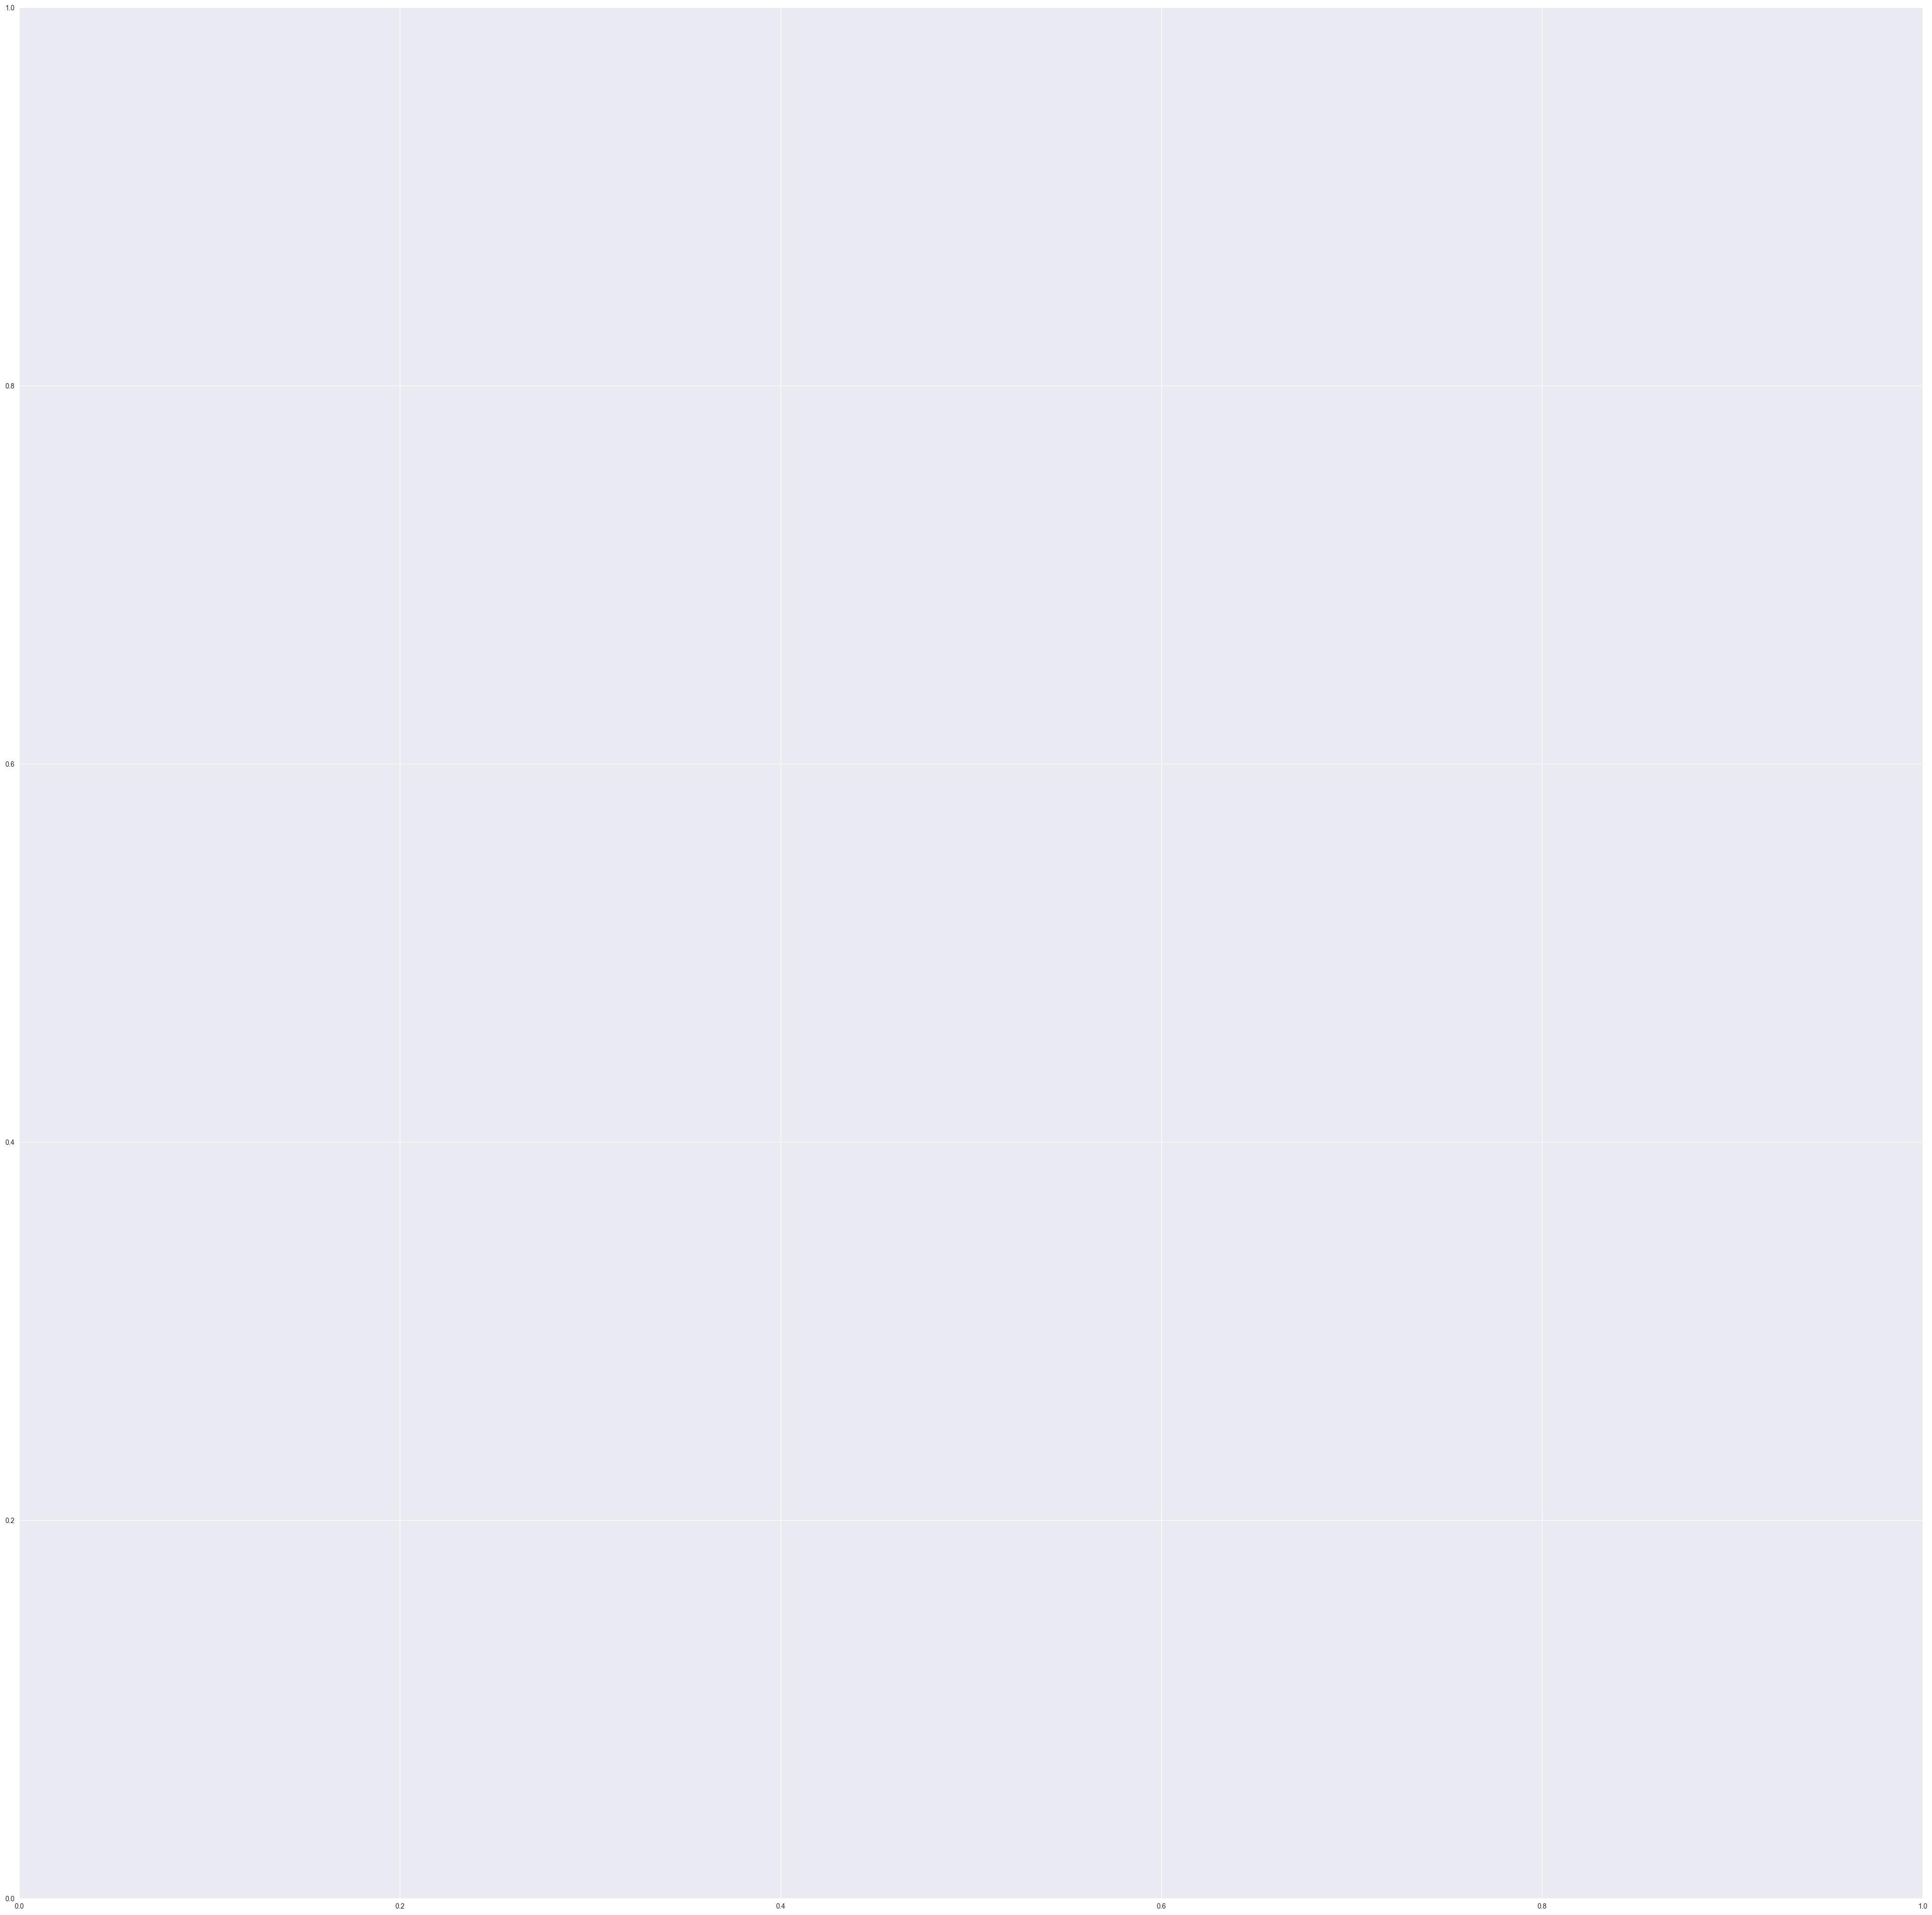

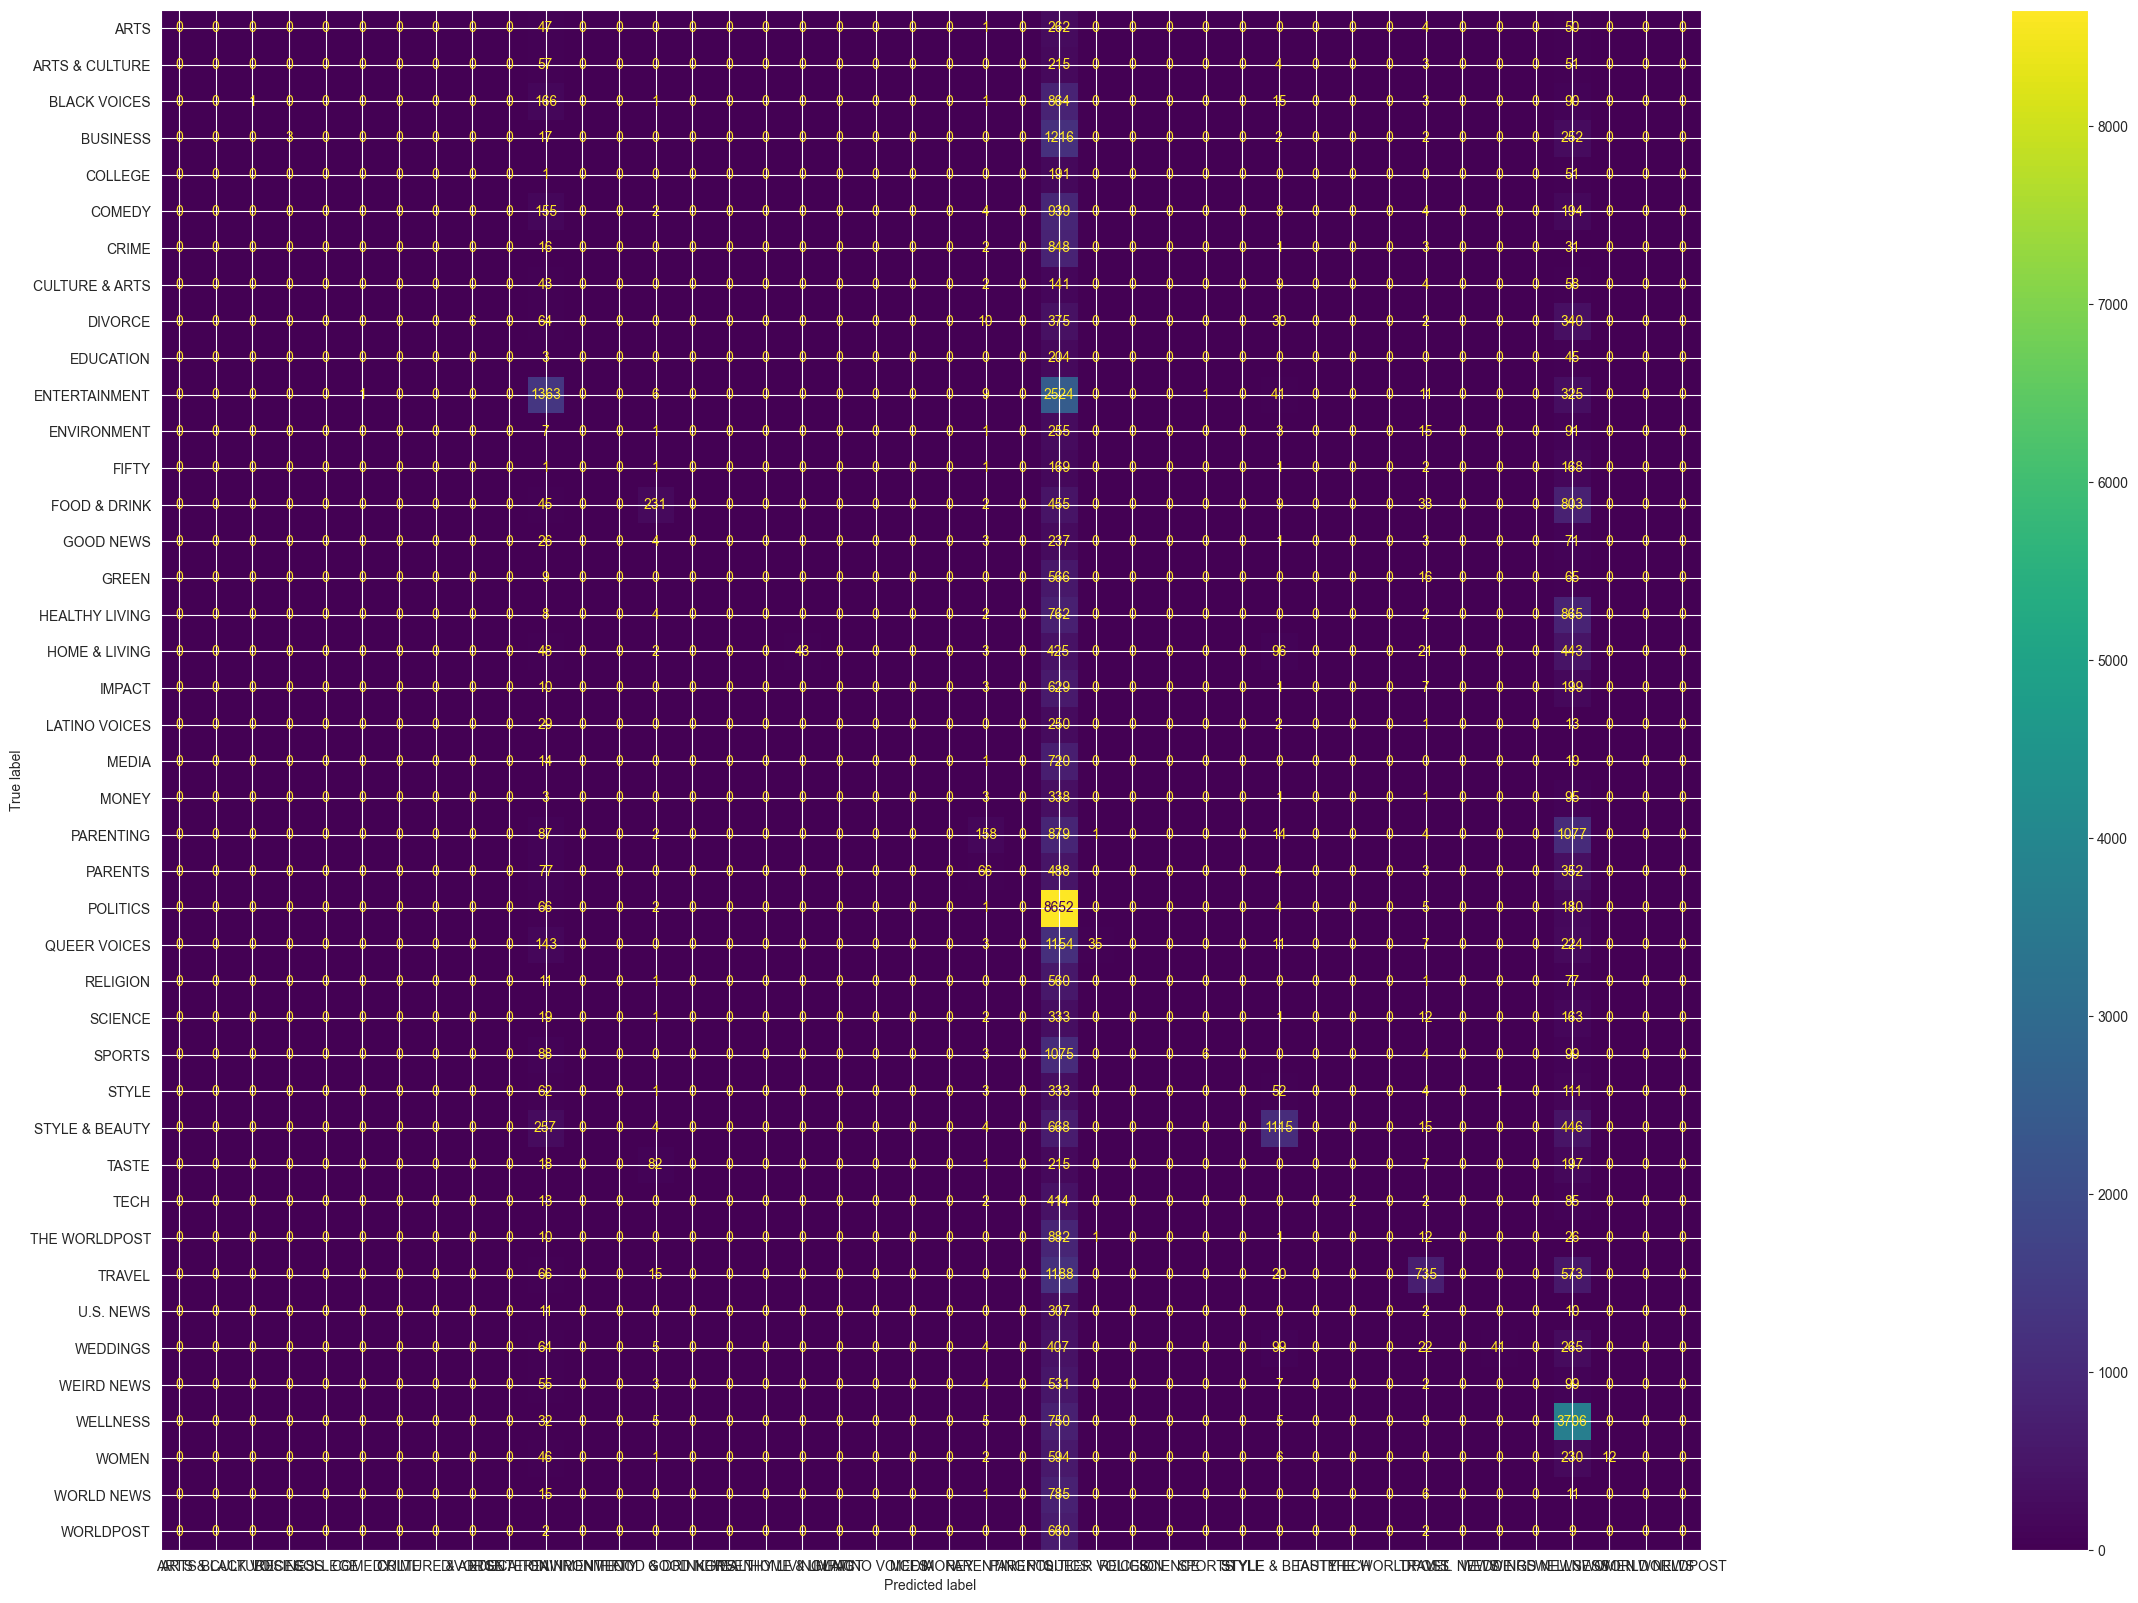

In [45]:
from sklearn.metrics import confusion_matrix
from sklearn.metrics import plot_confusion_matrix
import matplotlib.pyplot as plt
import numpy as np

fig, ax = plt.subplots(figsize=(50, 50))
plot_confusion_matrix(pipe, X_test, y_test)


## Using BERT to evaluate performance